In [3]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Зашумить изображение при помощи шума гаусса, постоянного шума.

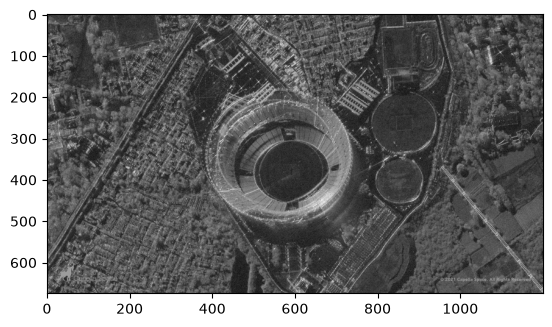

In [4]:
image = cv2.imread('sar_1.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
plt.imshow(image_gray, cmap="gray")

In [5]:
# Gaussian noise
mean = 0
stddev = 100
noise_gauss = np.zeros(image_gray.shape, np.uint8)
cv2.randn(noise_gauss, mean, stddev)

array([[  0,  16,   0, ..., 111,   0,  80],
       [  1, 104,  68, ...,   0, 103,   0],
       [  0,   0,  51, ...,   0,   0, 145],
       ...,
       [  0,   0,  39, ..., 255,   0,  15],
       [  0,  34,   0, ...,   0,   5, 135],
       [160, 204,   0, ...,  21,   0, 109]],
      shape=(675, 1200), dtype=uint8)

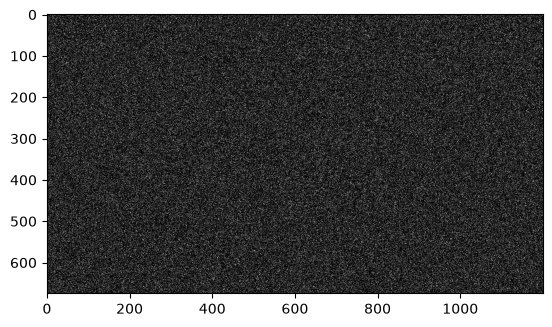

In [6]:
plt.imshow(noise_gauss, cmap="gray")

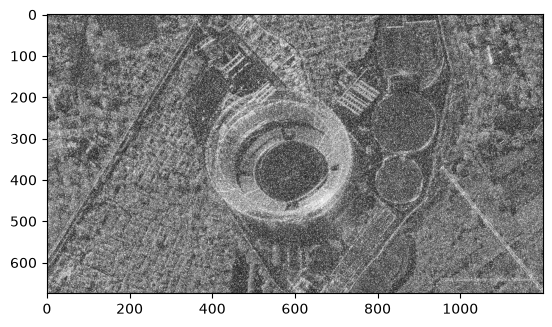

In [7]:
image_noise_gauss = cv2.add(image_gray, noise_gauss)
plt.imshow(image_noise_gauss, cmap="gray")

In [8]:
# Uniform noise
low = 0
high = 100
noise_uniform = np.zeros(image_gray.shape, np.uint8)
cv2.randu(noise_uniform, low, high)

array([[41, 79, 14, ..., 48, 32, 66],
       [77, 59, 13, ..., 27, 17, 95],
       [54, 48, 21, ..., 81, 97, 82],
       ...,
       [99, 97, 80, ..., 37, 64, 54],
       [40, 60, 76, ..., 53, 16, 83],
       [31,  1, 13, ..., 20, 40, 60]], shape=(675, 1200), dtype=uint8)

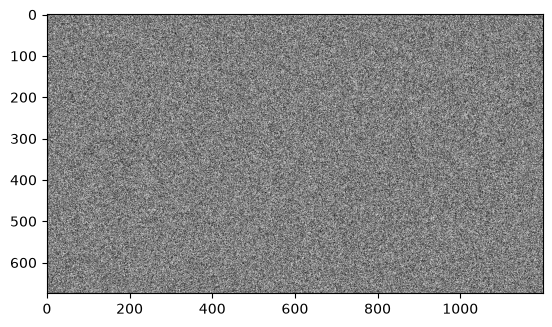

In [9]:
plt.imshow(noise_uniform, cmap="gray")

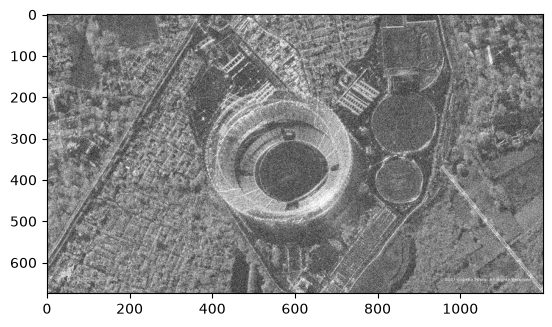

In [10]:
image_noise_uniform = cv2.add(image_gray, noise_uniform)
plt.imshow(image_noise_uniform, cmap="gray")

# Протестировать медианный фильтр, фильтр гаусса, билатериальный фильтр, фильтр нелокальных средних с различными параметрами.

In [11]:
from skimage.metrics import structural_similarity, mean_squared_error

## Медианный фильтр

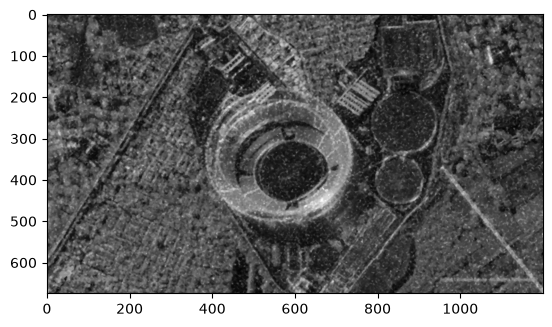

In [120]:
image_noise_gauss_median_1 = cv2.medianBlur(image_noise_gauss, 3)
image_noise_gauss_median_2 = cv2.medianBlur(image_noise_gauss, 5)
image_noise_gauss_median_3 = cv2.medianBlur(image_noise_gauss, 7)
plt.imshow(image_noise_gauss_median_2, cmap="gray")

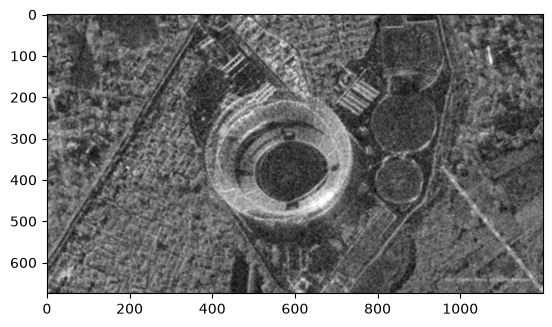

In [121]:
image_noise_uniform_median_1 = cv2.medianBlur(image_noise_uniform, 3)
image_noise_uniform_median_2 = cv2.medianBlur(image_noise_uniform, 5)
image_noise_uniform_median_3 = cv2.medianBlur(image_noise_uniform, 7)
plt.imshow(image_noise_uniform_median_2, cmap="gray")

### Гауссовский шум, медианный фильтр

In [122]:
mse_gauss_median_1 = mean_squared_error(image_gray, image_noise_gauss_median_1)
(ssim_gauss_median_1, diff) = structural_similarity(image_gray,  image_noise_gauss_median_1, full=True)
print(mse_gauss_median_1, ssim_gauss_median_1)

mse_gauss_median_2 = mean_squared_error(image_gray, image_noise_gauss_median_2)
(ssim_gauss_median_2, diff) = structural_similarity(image_gray,  image_noise_gauss_median_2, full=True)
print(mse_gauss_median_2, ssim_gauss_median_2)

mse_gauss_median_3 = mean_squared_error(image_gray, image_noise_gauss_median_3)
(ssim_gauss_median_3, diff) = structural_similarity(image_gray,  image_noise_gauss_median_3, full=True)
print(mse_gauss_median_3, ssim_gauss_median_3)

1038.0453432098766 0.42824305715634176
706.0308555555556 0.47015171101208536
682.5692432098765 0.4335541754151257


### Постоянный шум, медианный фильтр

In [123]:
mse_uniform_median_1 = mean_squared_error(image_gray, image_noise_uniform_median_1)
(ssim_uniform_median_1, diff) = structural_similarity(image_gray,  image_noise_uniform_median_1, full=True)
print(mse_uniform_median_1, ssim_uniform_median_1)

mse_uniform_median_2 = mean_squared_error(image_gray, image_noise_uniform_median_2)
(ssim_uniform_median_2, diff) = structural_similarity(image_gray,  image_noise_uniform_median_2, full=True)
print(mse_uniform_median_2, ssim_uniform_median_2)

mse_uniform_median_3 = mean_squared_error(image_gray, image_noise_uniform_median_3)
(ssim_uniform_median_3, diff) = structural_similarity(image_gray,  image_noise_uniform_median_3, full=True)
print(mse_uniform_median_3, ssim_uniform_median_3)

2758.157701234568 0.47889392717945106
2719.1172691358024 0.44659367959788737
2736.546075308642 0.39560504601763513


## Фильтр Гаусса

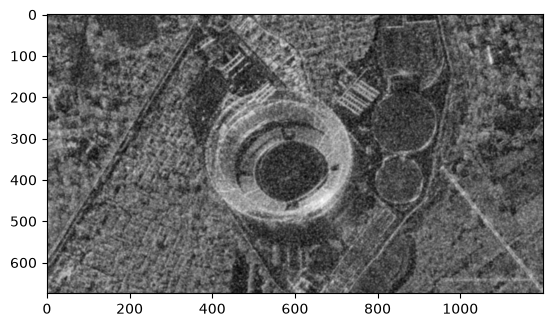

In [137]:
image_noise_gauss_gaussian_1 = cv2.GaussianBlur(image_noise_gauss, (5,5), 0)
image_noise_gauss_gaussian_2 = cv2.GaussianBlur(image_noise_gauss, (7,7), 0)
image_noise_gauss_gaussian_3 = cv2.GaussianBlur(image_noise_gauss, (9,9), 0)
plt.imshow(image_noise_gauss_gaussian_2, cmap="gray")

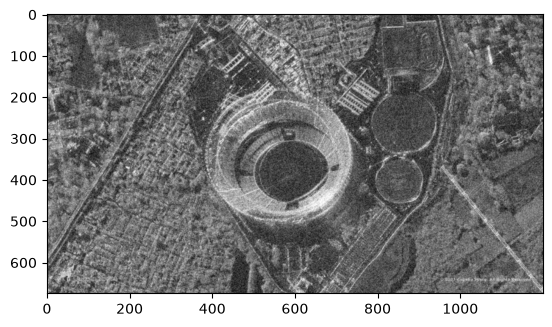

In [143]:
image_noise_uniform_gaussian_1 = cv2.GaussianBlur(image_noise_uniform, (3,3), 0)
image_noise_uniform_gaussian_2 = cv2.GaussianBlur(image_noise_uniform, (5,5), 0)
image_noise_uniform_gaussian_3 = cv2.GaussianBlur(image_noise_uniform, (7,7), 0)
plt.imshow(image_noise_uniform_gaussian_1, cmap="gray")

### Гауссовский шум, фильтр Гаусса

In [144]:
mse_gauss_gaussian_1 = mean_squared_error(image_gray, image_noise_gauss_gaussian_1)
(ssim_gauss_gaussian_1, diff) = structural_similarity(image_gray,  image_noise_gauss_gaussian_1, full=True)
print(mse_gauss_gaussian_1, ssim_gauss_gaussian_1)

mse_gauss_gaussian_2 = mean_squared_error(image_gray, image_noise_gauss_gaussian_2)
(ssim_gauss_gaussian_2, diff) = structural_similarity(image_gray,  image_noise_gauss_gaussian_2, full=True)
print(mse_gauss_gaussian_2, ssim_gauss_gaussian_2)

mse_gauss_gaussian_3 = mean_squared_error(image_gray, image_noise_gauss_gaussian_3)
(ssim_gauss_gaussian_3, diff) = structural_similarity(image_gray,  image_noise_gauss_gaussian_3, full=True)
print(mse_gauss_gaussian_3, ssim_gauss_gaussian_3)

1764.6416320987655 0.48595844595449306
1721.1959543209878 0.49254914446712594
1719.8958962962963 0.4789807575987752


### Постоянный шум, фильтр Гаусса

In [145]:
mse_uniform_gaussian_1 = mean_squared_error(image_gray, image_noise_uniform_gaussian_1)
(ssim_uniform_gaussian_1, diff) = structural_similarity(image_gray,  image_noise_uniform_gaussian_1, full=True)
print(mse_uniform_gaussian_1, ssim_uniform_gaussian_1)

mse_uniform_gaussian_2 = mean_squared_error(image_gray, image_noise_uniform_gaussian_2)
(ssim_uniform_gaussian_2, diff) = structural_similarity(image_gray,  image_noise_uniform_gaussian_2, full=True)
print(mse_uniform_gaussian_2, ssim_uniform_gaussian_2)

mse_uniform_gaussian_3 = mean_squared_error(image_gray, image_noise_uniform_gaussian_3)
(ssim_uniform_gaussian_3, diff) = structural_similarity(image_gray,  image_noise_uniform_gaussian_3, full=True)
print(mse_uniform_gaussian_3, ssim_uniform_gaussian_3)

2634.3047938271607 0.6028595316341641
2623.384037037037 0.5991001180512758
2647.7386679012347 0.5564030754665985


## Билатериальный фильтр

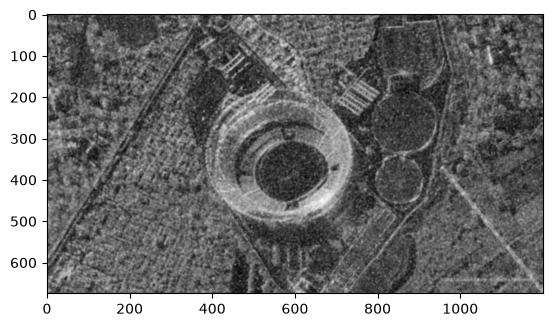

In [227]:
image_noise_gauss_bilat_1 = cv2.bilateralFilter(image_noise_gauss, 7, 100, 15)
image_noise_gauss_bilat_2 = cv2.bilateralFilter(image_noise_gauss, 7, 150, 15)
image_noise_gauss_bilat_3 = cv2.bilateralFilter(image_noise_gauss, 7, 200, 15)
plt.imshow(image_noise_gauss_bilat_2, cmap="gray")

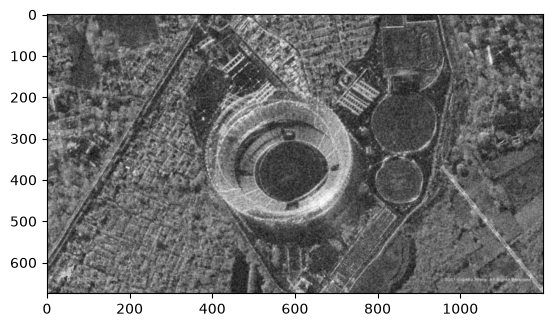

In [228]:
image_noise_uniform_bilat_1 = cv2.bilateralFilter(image_noise_uniform, 5, 50, 15)
image_noise_uniform_bilat_2 = cv2.bilateralFilter(image_noise_uniform, 5, 75, 15)
image_noise_uniform_bilat_3 = cv2.bilateralFilter(image_noise_uniform, 5, 100, 15)
plt.imshow(image_noise_uniform_bilat_2, cmap="gray")

### Гауссовский шум, билатериальный фильтр

In [229]:
mse_gauss_bilat_1 = mean_squared_error(image_gray, image_noise_gauss_bilat_1)
(ssim_gauss_bilat_1, diff) = structural_similarity(image_gray,  image_noise_gauss_bilat_1, full=True)
print(mse_gauss_bilat_1, ssim_gauss_bilat_1)

mse_gauss_bilat_2 = mean_squared_error(image_gray, image_noise_gauss_bilat_2)
(ssim_gauss_bilat_2, diff) = structural_similarity(image_gray,  image_noise_gauss_bilat_2, full=True)
print(mse_gauss_bilat_2, ssim_gauss_bilat_2)

mse_gauss_bilat_3 = mean_squared_error(image_gray, image_noise_gauss_bilat_3)
(ssim_gauss_bilat_3, diff) = structural_similarity(image_gray,  image_noise_gauss_bilat_3, full=True)
print(mse_gauss_bilat_3, ssim_gauss_bilat_3)

1594.9747950617284 0.40379036939530133
1557.0322061728396 0.4617722081699374
1611.2545086419752 0.46442307618685985


### Постоянный шум, билатериальный фильтр

In [205]:
mse_uniform_bilat_1 = mean_squared_error(image_gray, image_noise_uniform_bilat_1)
(ssim_uniform_bilat_1, diff) = structural_similarity(image_gray,  image_noise_uniform_bilat_1, full=True)
print(mse_uniform_bilat_1, ssim_uniform_bilat_1)

mse_uniform_bilat_2 = mean_squared_error(image_gray, image_noise_uniform_bilat_2)
(ssim_uniform_bilat_2, diff) = structural_similarity(image_gray,  image_noise_uniform_bilat_2, full=True)
print(mse_uniform_bilat_2, ssim_uniform_bilat_2)

mse_uniform_bilat_3 = mean_squared_error(image_gray, image_noise_uniform_bilat_3)
(ssim_uniform_bilat_3, diff) = structural_similarity(image_gray,  image_noise_uniform_bilat_3, full=True)
print(mse_uniform_bilat_3, ssim_uniform_bilat_3)

2620.728550617284 0.566117156033306
2582.4010444444443 0.5888323290170588
2583.4407407407407 0.5827620371278934


## Фильтр нелокальных средних

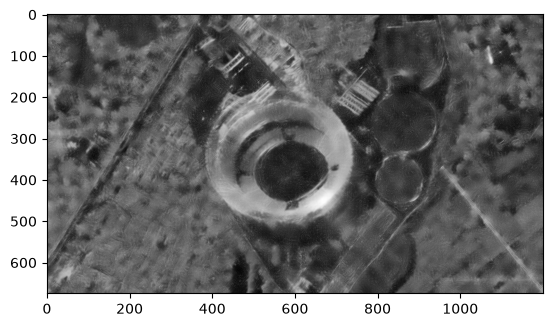

In [111]:
image_noise_gauss_nlm_1 = cv2.fastNlMeansDenoising(image_noise_gauss, h = 20)
image_noise_gauss_nlm_2 = cv2.fastNlMeansDenoising(image_noise_gauss, h = 45)
image_noise_gauss_nlm_3 = cv2.fastNlMeansDenoising(image_noise_gauss, h = 50)
plt.imshow(image_noise_gauss_nlm_2, cmap="gray")

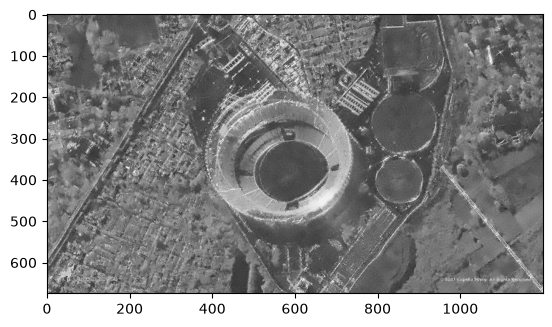

In [112]:
image_noise_uniform_nlm_1 = cv2.fastNlMeansDenoising(image_noise_uniform, h = 5)
image_noise_uniform_nlm_2 = cv2.fastNlMeansDenoising(image_noise_uniform, h = 20)
image_noise_uniform_nlm_3 = cv2.fastNlMeansDenoising(image_noise_uniform, h = 45)
plt.imshow(image_noise_uniform_nlm_2, cmap="gray")

### Гауссовский шум, фильтр нелокальных средних

In [109]:
mse_gauss_nlm_1 = mean_squared_error(image_gray, image_noise_gauss_nlm_1)
(ssim_gauss_nlm_1, diff) = structural_similarity(image_gray,  image_noise_gauss_nlm_1, full=True)
print(mse_gauss_nlm_1, ssim_gauss_nlm_1)

mse_gauss_nlm_2 = mean_squared_error(image_gray, image_noise_gauss_nlm_2)
(ssim_gauss_nlm_2, diff) = structural_similarity(image_gray,  image_noise_gauss_nlm_2, full=True)
print(mse_gauss_nlm_2, ssim_gauss_nlm_2)

mse_gauss_nlm_3 = mean_squared_error(image_gray, image_noise_gauss_nlm_3)
(ssim_gauss_nlm_3, diff) = structural_similarity(image_gray,  image_noise_gauss_nlm_3, full=True)
print(mse_gauss_nlm_3, ssim_gauss_nlm_3)

4226.2362469135805 0.18739500765448647
1740.4901938271605 0.38004144700758735
1761.598712345679 0.361132713775064


### Постоянный шум, фильтр нелокальных средних

In [110]:
mse_uniform_nlm_1 = mean_squared_error(image_gray, image_noise_uniform_nlm_1)
(ssim_uniform_nlm_1, diff) = structural_similarity(image_gray,  image_noise_uniform_nlm_1, full=True)
print(mse_uniform_nlm_1, ssim_uniform_nlm_1)

mse_uniform_nlm_2 = mean_squared_error(image_gray, image_noise_uniform_nlm_2)
(ssim_uniform_nlm_2, diff) = structural_similarity(image_gray,  image_noise_uniform_nlm_2, full=True)
print(mse_uniform_nlm_2, ssim_uniform_nlm_2)

mse_uniform_nlm_3 = mean_squared_error(image_gray, image_noise_uniform_nlm_3)
(ssim_uniform_nlm_3, diff) = structural_similarity(image_gray,  image_noise_uniform_nlm_3, full=True)
print(mse_uniform_nlm_3, ssim_uniform_nlm_3)

3278.861885185185 0.36851697608057604
2722.5115938271606 0.5356889265595346
2738.3822111111112 0.34816455770339494


# Выяснить, какой фильтр показал лучший результат фильтрации шума.

In [ ]:
# Гауссовский шум, медианный фильтр 706.0308555555556 0.47015171101208536
# Гауссовский шум, билатериальный фильтр 1557.0322061728396 0.4617722081699374
# Гауссовский шум, фильтр Гаусса 1721.1959543209878 0.49254914446712594
# Гауссовский шум, фильтр нелокальных средних 1740.4901938271605 0.38004144700758735

# Постоянный шум, билатериальный фильтр 2582.4010444444443 0.5888323290170588
# Постоянный шум, фильтр Гаусса 2634.3047938271607 0.6028595316341641
# Постоянный шум, фильтр нелокальных средних 2722.5115938271606 0.5356889265595346
# Постоянный шум, медианный фильтр 2719.1172691358024 0.44659367959788737

# Итог: 
# для шума Гаусса - medianBlur(5)
# для постоянного шума - bilateralFilter(5, 75, 15) / GaussianBlur((3,3), 0)